In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

### 1. Cargar Dataset

In [ ]:
df = pd.read_parquet("../datos_credito.parquet")
df.head()

,edad,personas_a_cargo,ingreso_mensual,monto_solicitado,plazo_meses,cuota_estimada,score_crediticio,dti_previo,dti_total_proyectado,aprobado
0,61,2,1791000.0,3830000.0,24,197900.0,650,0.465,0.576,1
1,42,5,1200000.0,2720000.0,60,74500.0,705,0.288,0.350,1
2,30,0,3210000.0,22740000.0,12,2124000.0,626,0.168,0.830,1
3,40,2,1549000.0,5020000.0,48,157100.0,576,0.027,0.128,0
4,25,1,1200000.0,9120000.0,36,346400.0,439,0.129,0.418,1


### 2. Exploración inicial de los datos

In [10]:
# Dimensiones del dataset
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 15,000
Columnas: 10


In [11]:
# columnas y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edad                  15000 non-null  int64  
 1   personas_a_cargo      15000 non-null  int64  
 2   ingreso_mensual       15000 non-null  float64
 3   monto_solicitado      15000 non-null  float64
 4   plazo_meses           15000 non-null  int64  
 5   cuota_estimada        15000 non-null  float64
 6   score_crediticio      15000 non-null  int64  
 7   dti_previo            15000 non-null  float64
 8   dti_total_proyectado  15000 non-null  float64
 9   aprobado              15000 non-null  int64  
dtypes: float64(5), int64(5)
memory usage: 1.1 MB


In [12]:
# Valores nulos por columna
df.isna().sum()

edad                    0
personas_a_cargo        0
ingreso_mensual         0
monto_solicitado        0
plazo_meses             0
cuota_estimada          0
score_crediticio        0
dti_previo              0
dti_total_proyectado    0
aprobado                0
dtype: int64

In [13]:
# Duplicados
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


### 3. Estadisticas descriptivas

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,15000.0,4.603953e+01,1.643786e+01,18.000,32.000,4.600000e+01,6.000000e+01,7.400000e+01
personas_a_cargo,15000.0,1.171333e+00,1.255050e+00,0.000,0.000,1.000000e+00,2.000000e+00,5.000000e+00
ingreso_mensual,15000.0,3.210395e+06,2.049901e+06,1200000.000,1782750.000,2.660000e+06,3.976250e+06,2.409500e+07
monto_solicitado,15000.0,1.517323e+07,1.200859e+07,1800000.000,7200000.000,1.178000e+07,1.928250e+07,1.423200e+08
plazo_meses,15000.0,3.424480e+01,1.437215e+01,12.000,24.000,3.600000e+01,4.800000e+01,6.000000e+01
cuota_estimada,15000.0,7.162709e+05,6.867108e+05,50700.000,292500.000,5.088000e+05,8.938000e+05,1.086260e+07
score_crediticio,15000.0,6.191656e+02,1.079697e+02,300.000,546.000,6.200000e+02,6.940000e+02,8.500000e+02
dti_previo,15000.0,2.849545e-01,1.597737e-01,0.002,0.160,2.640000e-01,3.880000e-01,8.000000e-01
dti_total_proyectado,15000.0,5.091997e-01,2.125860e-01,0.067,0.353,4.800000e-01,6.380000e-01,1.515000e+00
aprobado,15000.0,6.607333e-01,4.734762e-01,0.000,0.000,1.000000e+00,1.000000e+00,1.000000e+00


### 4. Variable objetivo

In [15]:
conteo_aprobado = df["aprobado"].value_counts().sort_index()
porcentaje_aprobado = (df["aprobado"].value_counts(normalize=True).sort_index() * 100).round(2)

pd.DataFrame({
    "cantidad": conteo_aprobado,
    "porcentaje": porcentaje_aprobado,
})

,cantidad,porcentaje
aprobado,,
0,5089,33.93
1,9911,66.07


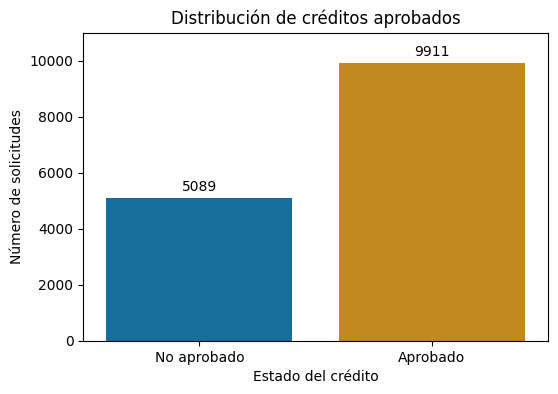

In [37]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="aprobado", hue="aprobado", palette="colorblind", legend=False)

plt.title("Distribución de créditos aprobados")
plt.xlabel("Estado del crédito")
plt.ylabel("Número de solicitudes")
plt.xticks([0, 1], ["No aprobado", "Aprobado"])

ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)

plt.ylim(0, 11000)

plt.show()

### 5. Distribución variables númericas

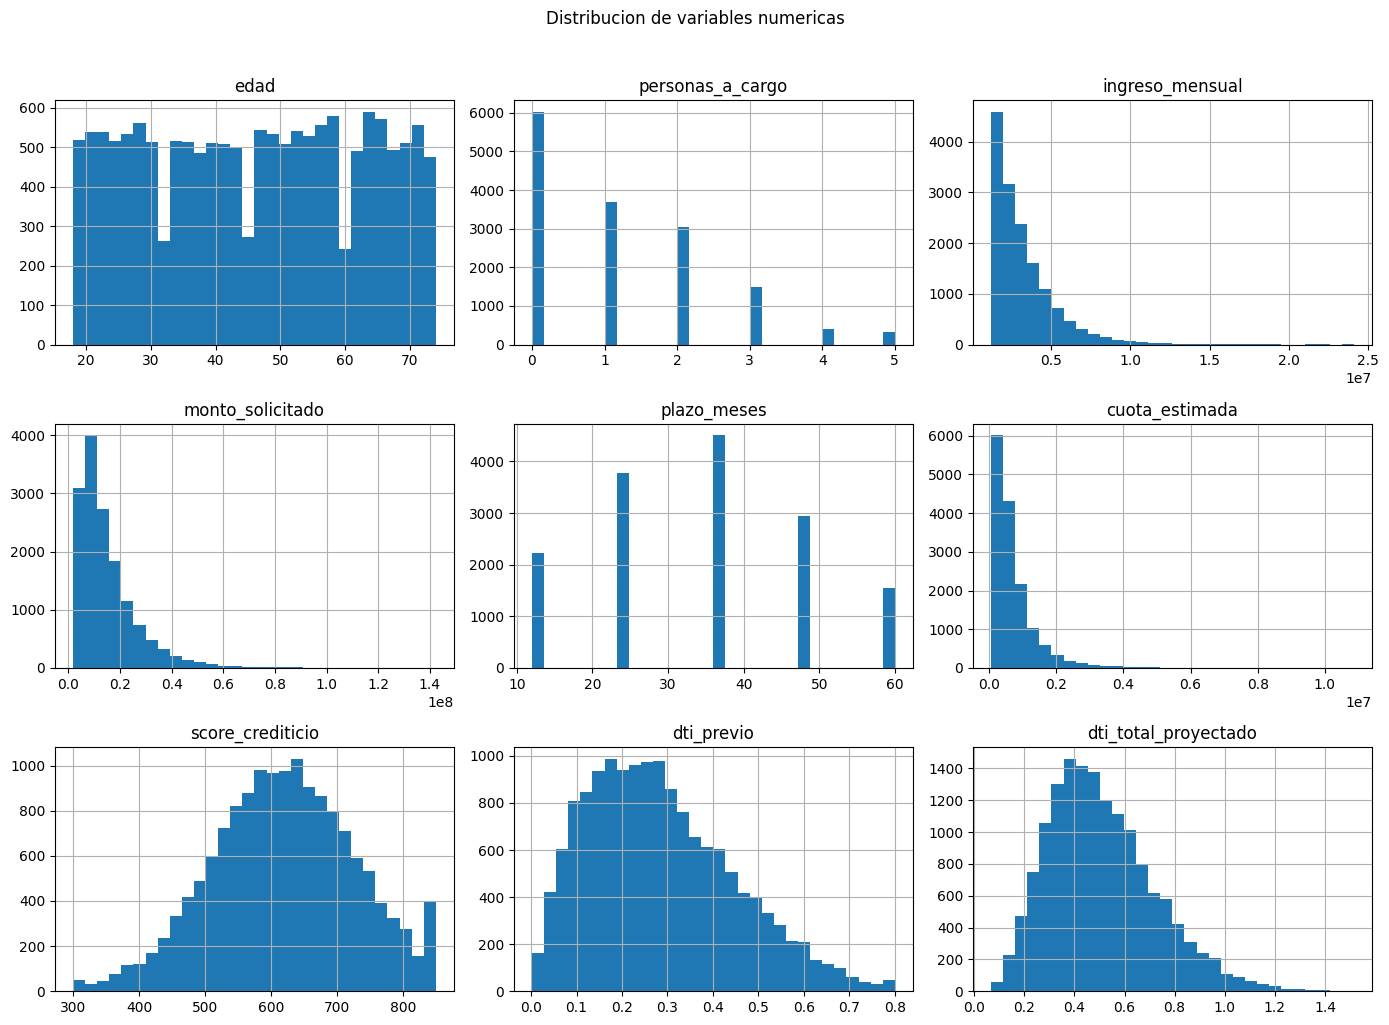

In [17]:
columnas_numericas = df.drop(columns=["aprobado"]).columns.tolist()

df[columnas_numericas].hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribucion de variables numericas", y=1.02)
plt.tight_layout()
plt.show()

### 6. Boxplots

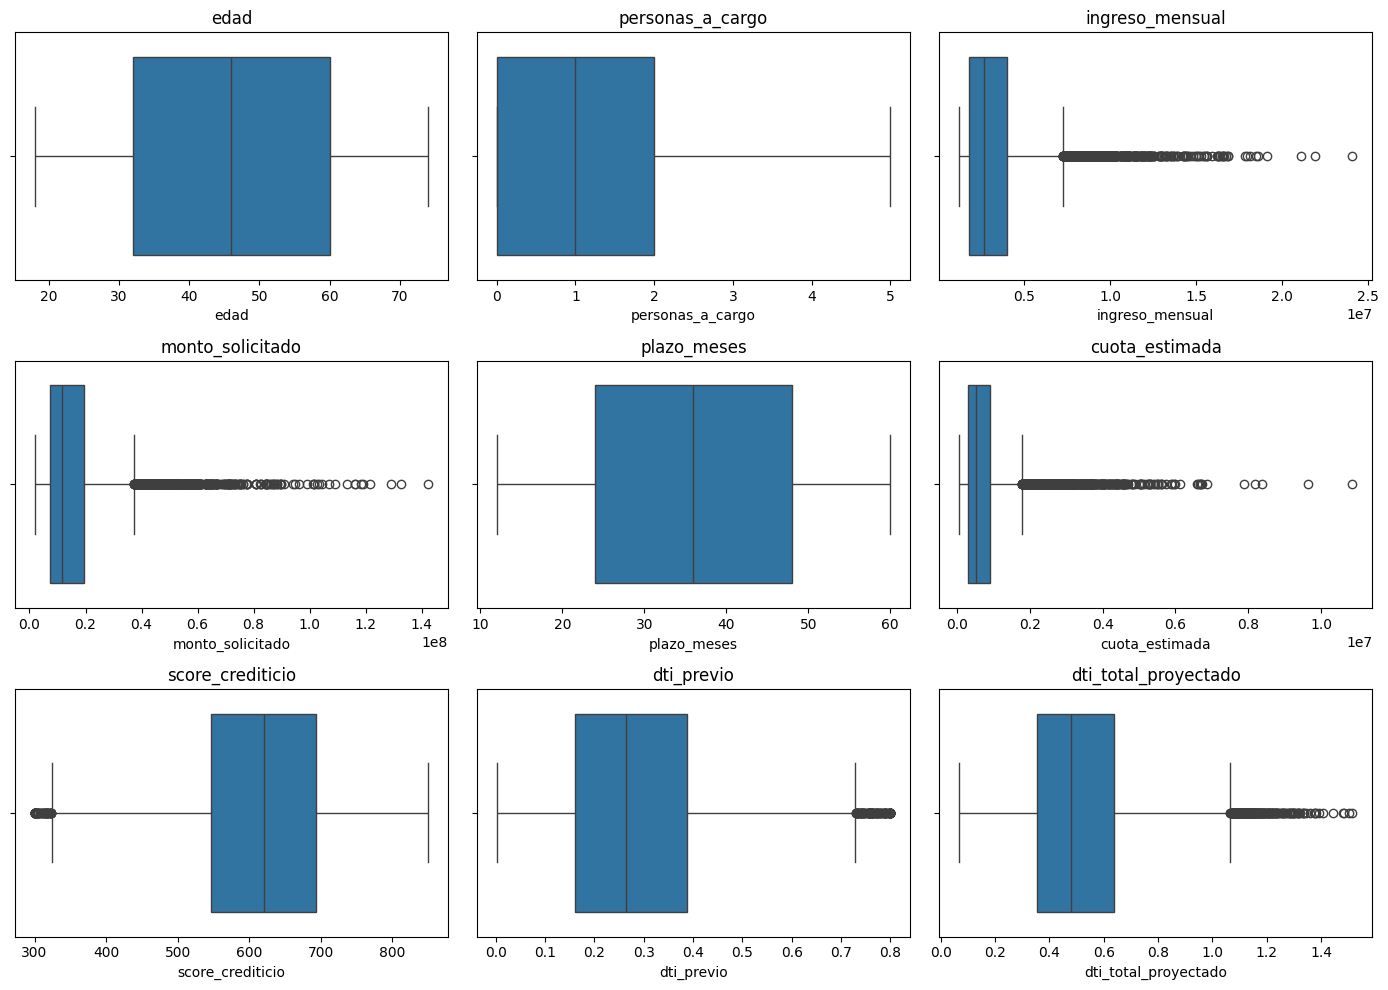

In [18]:
plt.figure(figsize=(14, 10))

for i, columna in enumerate(columnas_numericas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[columna])
    plt.title(columna)

plt.tight_layout()
plt.show()

### 7. Promedios por clase

In [19]:
df.groupby("aprobado")[columnas_numericas].mean().T

aprobado,0,1
edad,4.596188e+01,4.607941e+01
personas_a_cargo,1.284732e+00,1.113107e+00
ingreso_mensual,2.913641e+06,3.362769e+06
monto_solicitado,1.474983e+07,1.539063e+07
plazo_meses,3.147730e+01,3.566583e+01
cuota_estimada,7.808941e+05,6.830889e+05
score_crediticio,5.755054e+02,6.415838e+02
dti_previo,3.324818e-01,2.605507e-01
dti_total_proyectado,5.988068e-01,4.631892e-01


### 8. Boxplots por aprobación

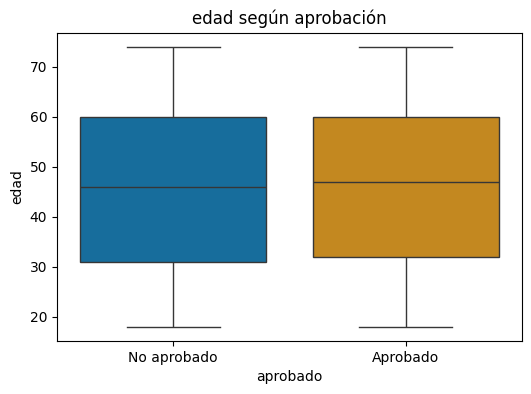

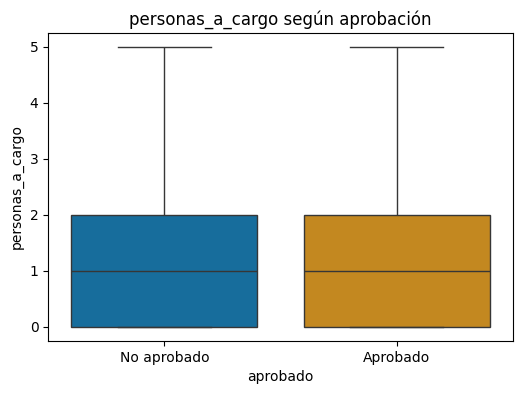

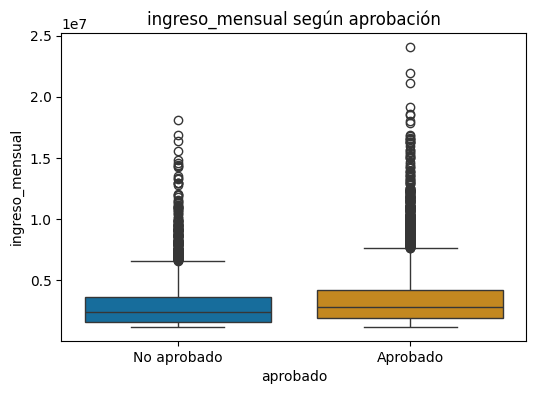

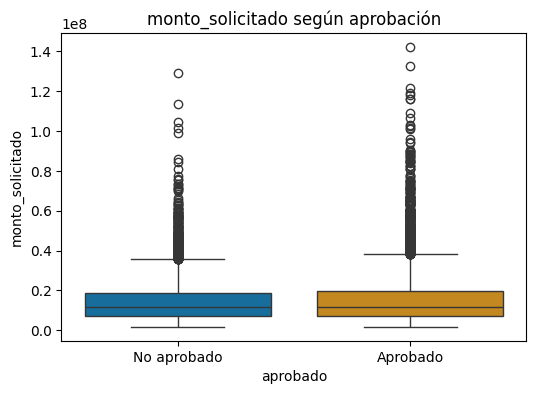

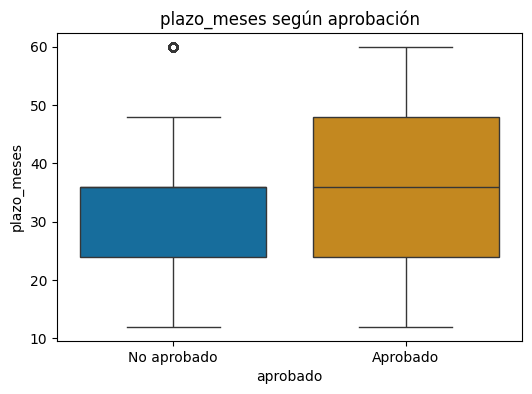

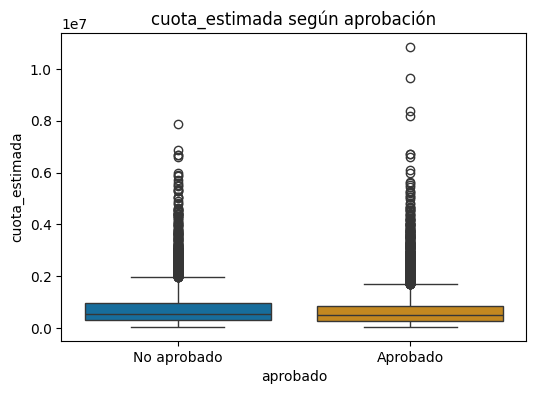

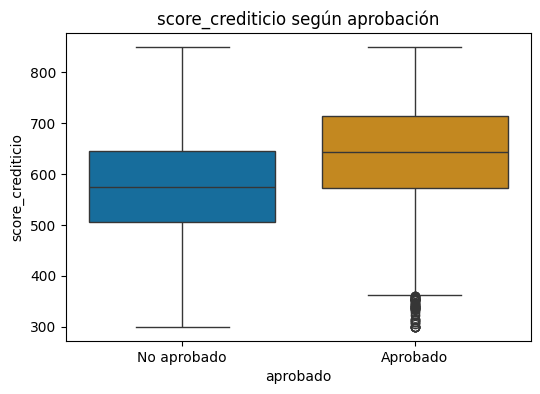

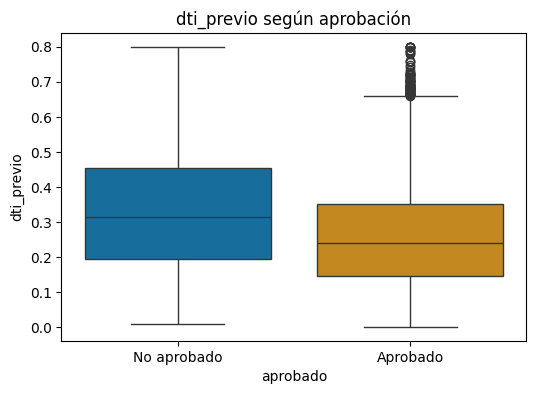

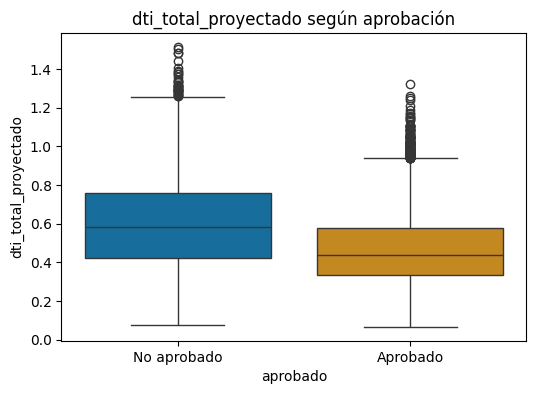

In [36]:
for columna in columnas_numericas:

    plt.figure(figsize=(6, 4))

    sns.boxplot(data=df, x="aprobado", y=columna, hue="aprobado", palette="colorblind", legend=False)

    plt.xticks([0, 1], ["No aprobado", "Aprobado"])
    plt.title(f"{columna} según aprobación")

    plt.show()

### 9. Matriz de correlaciones

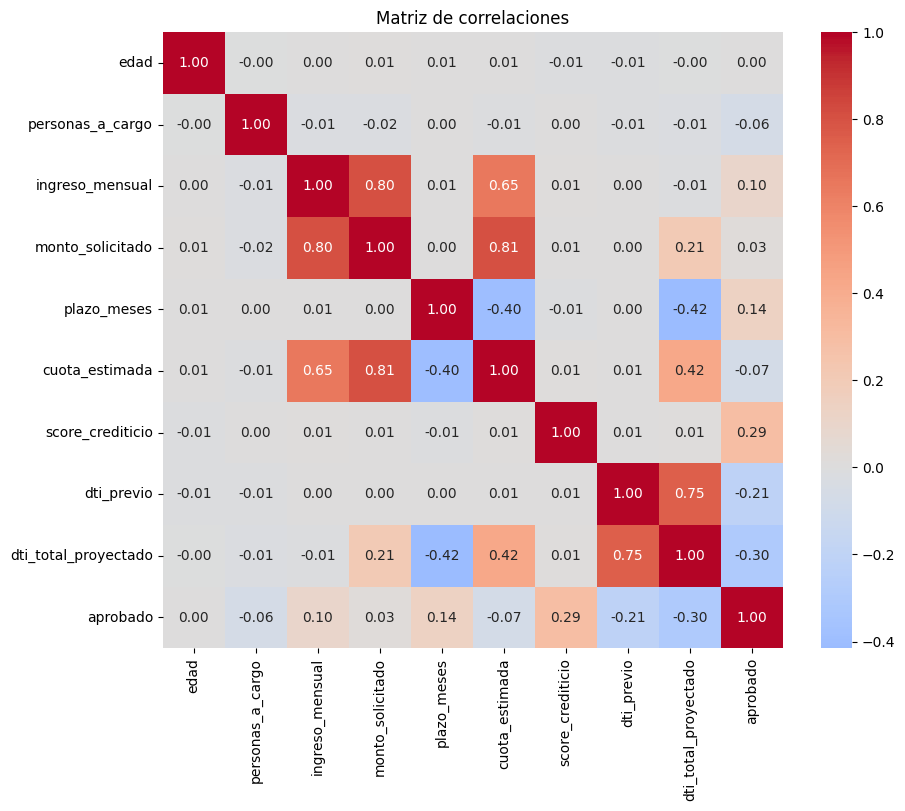

In [21]:
correlaciones = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlaciones,annot=True,fmt=".2f",cmap="coolwarm",center=0)

plt.title("Matriz de correlaciones")
plt.show()

### 10. Correlación con variable objetivo

In [22]:
correlacion_aprobado = (correlaciones["aprobado"].drop("aprobado").sort_values())

correlacion_aprobado

dti_total_proyectado   -0.302051
dti_previo             -0.213162
cuota_estimada         -0.067435
personas_a_cargo       -0.064747
edad                    0.003385
monto_solicitado        0.025266
ingreso_mensual         0.103737
plazo_meses             0.137987
score_crediticio        0.289772
Name: aprobado, dtype: float64

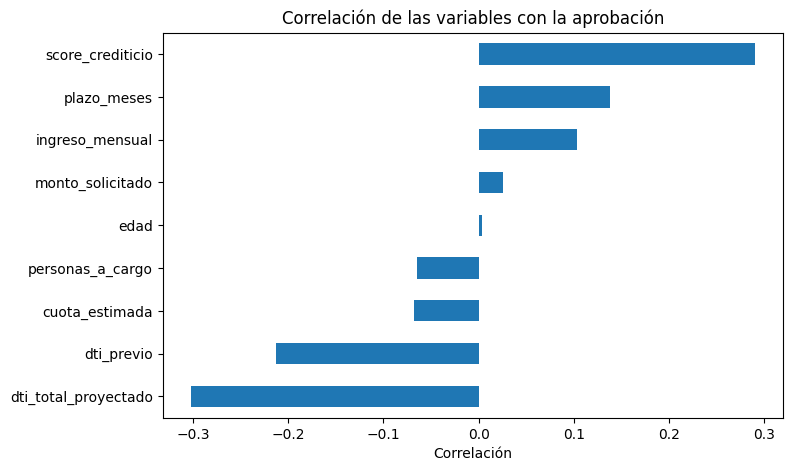

In [23]:
correlacion_aprobado.plot(kind="barh",figsize=(8, 5))

plt.title("Correlación de las variables con la aprobación")
plt.xlabel("Correlación")

plt.show()

### 11. Distribuciones Por Aprobado Y No Aprobado

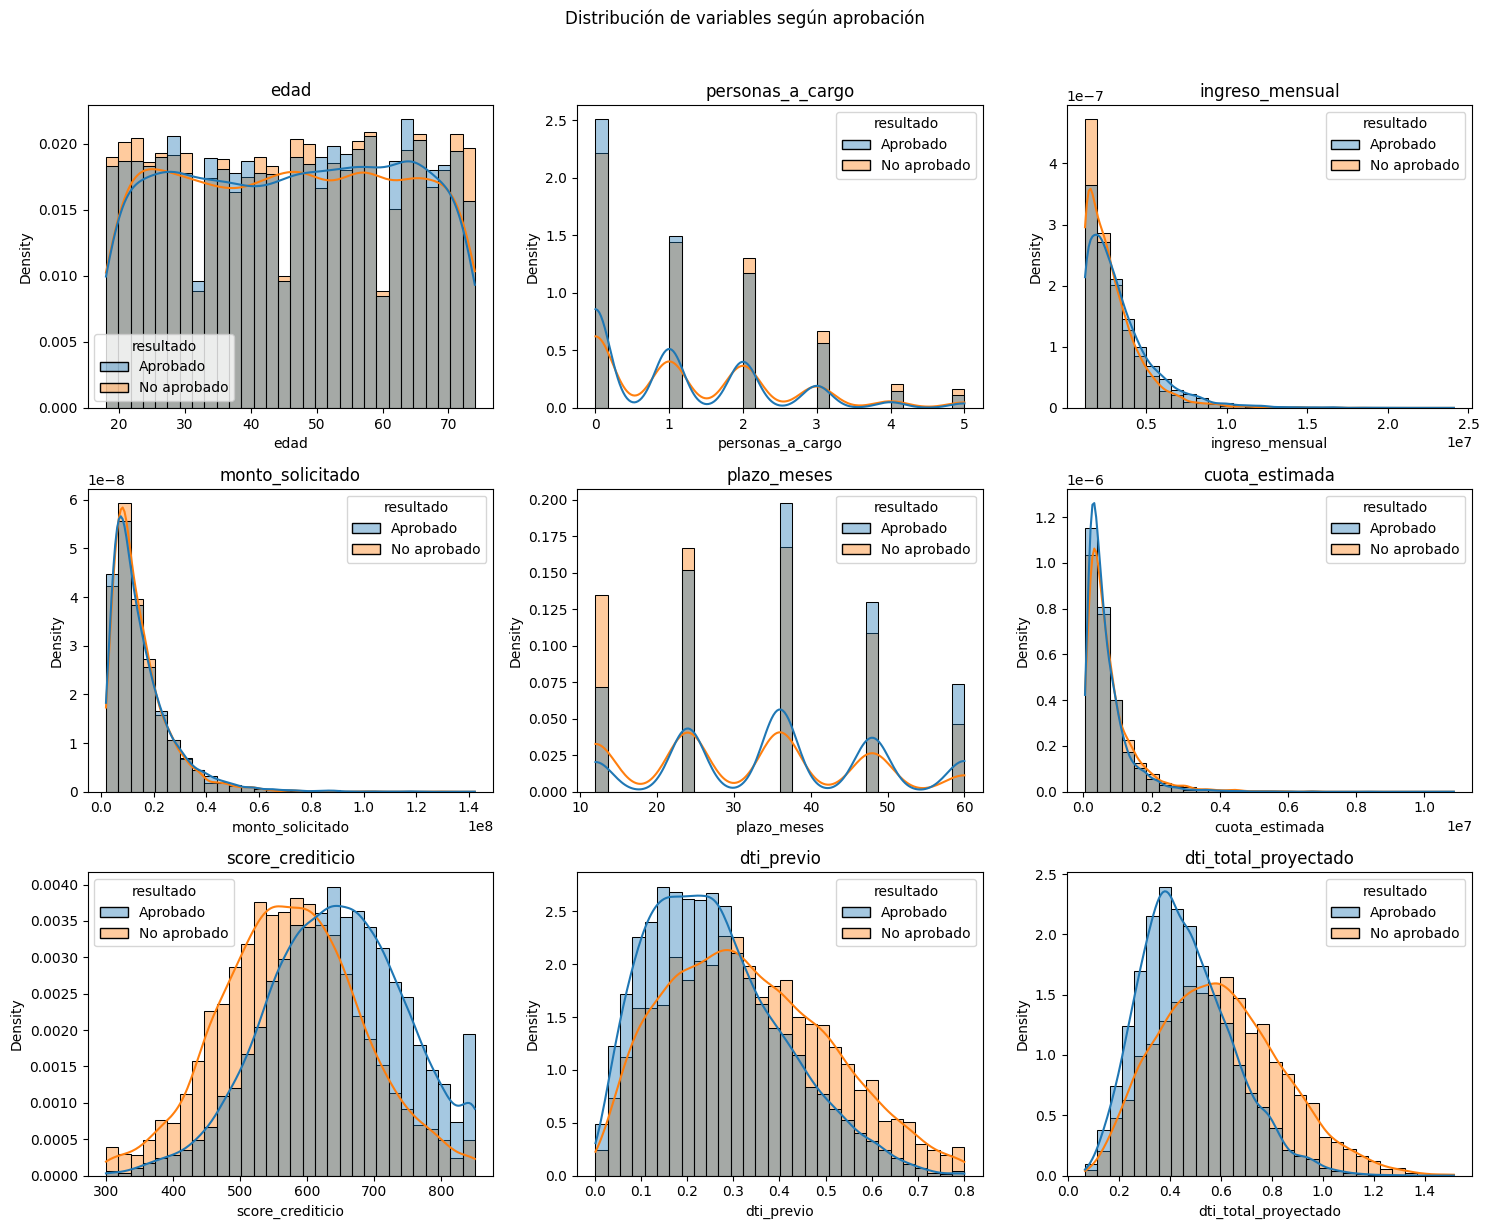

In [24]:
df["resultado"] = df["aprobado"].map({
    0: "No aprobado",
    1: "Aprobado"
})

columnas_numericas = df.drop(columns=["aprobado", "resultado"]).columns.tolist()

n_columnas = 3
n_filas = math.ceil(len(columnas_numericas) / n_columnas)

fig, axes = plt.subplots(n_filas, n_columnas, figsize=(15, 4 * n_filas))
axes = axes.flatten()

for i, columna in enumerate(columnas_numericas):
    sns.histplot(
        data=df,
        x=columna,
        hue="resultado",
        kde=True,
        bins=30,
        stat="density",
        common_norm=False,
        alpha=0.4,
        ax=axes[i]
    )
    axes[i].set_title(columna)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de variables según aprobación", y=1.02)
plt.tight_layout()
plt.show()

### 12. Aprobación por variables

### Edad

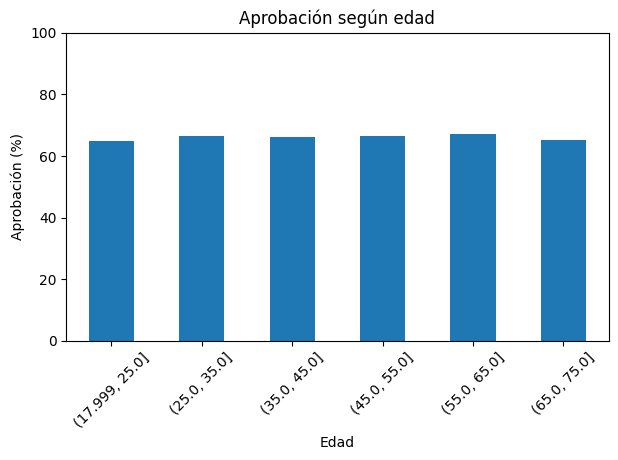

In [25]:
df["grupo_edad"] = pd.cut(
    df["edad"],
    bins=[18, 25, 35, 45, 55, 65, 75],
    include_lowest=True
)

aprobacion_edad = df.groupby(
    "grupo_edad",
    observed=True
)["aprobado"].mean() * 100

aprobacion_edad.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Aprobación según edad")
plt.ylabel("Aprobación (%)")
plt.xlabel("Edad")
plt.ylim(0, 100)
plt.xticks(rotation=45)

plt.show()

### Personas a cargo

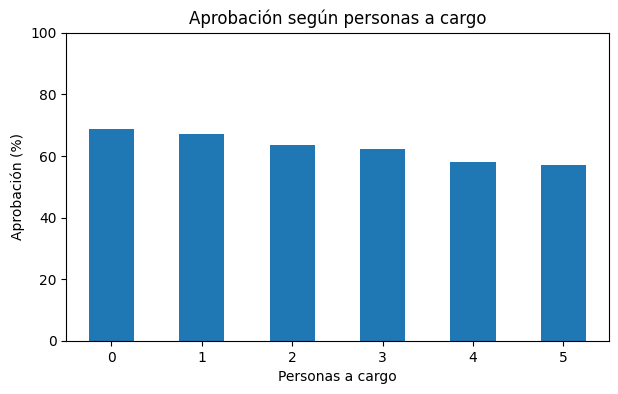

In [26]:
aprobacion_personas = df.groupby(
    "personas_a_cargo"
)["aprobado"].mean() * 100

aprobacion_personas.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Aprobación según personas a cargo")
plt.ylabel("Aprobación (%)")
plt.xlabel("Personas a cargo")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

### Ingreso mensual

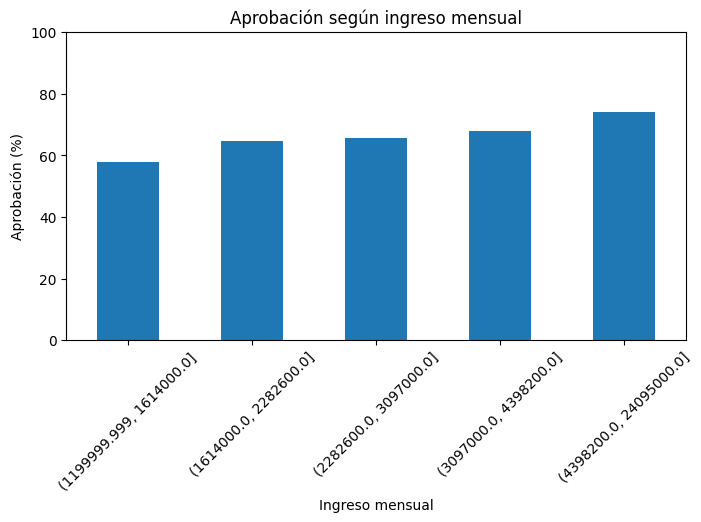

In [27]:
df["grupo_ingreso"] = pd.qcut(
    df["ingreso_mensual"],
    q=5,
    duplicates="drop"
)

aprobacion_ingreso = df.groupby(
    "grupo_ingreso",
    observed=True
)["aprobado"].mean() * 100

aprobacion_ingreso.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Aprobación según ingreso mensual")
plt.ylabel("Aprobación (%)")
plt.xlabel("Ingreso mensual")
plt.ylim(0, 100)
plt.xticks(rotation=45)

plt.show()

### Monto solicitado

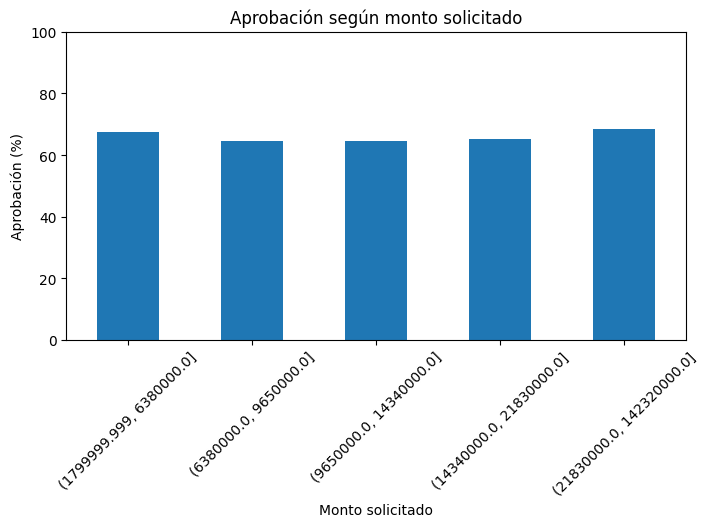

In [28]:
df["grupo_monto"] = pd.qcut(
    df["monto_solicitado"],
    q=5,
    duplicates="drop"
)

aprobacion_monto = df.groupby(
    "grupo_monto",
    observed=True
)["aprobado"].mean() * 100

aprobacion_monto.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Aprobación según monto solicitado")
plt.ylabel("Aprobación (%)")
plt.xlabel("Monto solicitado")
plt.ylim(0, 100)
plt.xticks(rotation=45)

plt.show()

### Plazo

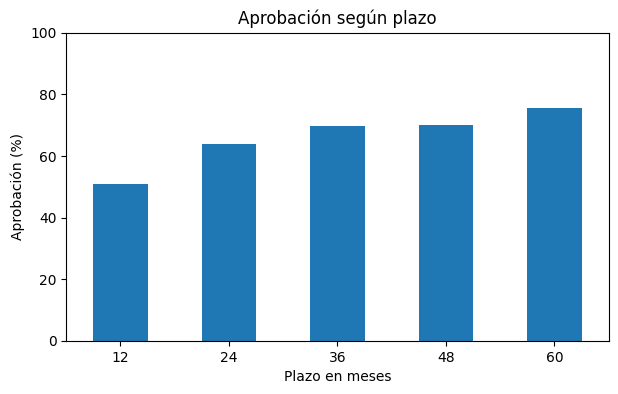

In [29]:
aprobacion_plazo = df.groupby(
    "plazo_meses"
)["aprobado"].mean() * 100

aprobacion_plazo.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Aprobación según plazo")
plt.ylabel("Aprobación (%)")
plt.xlabel("Plazo en meses")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

### Cuota estimada

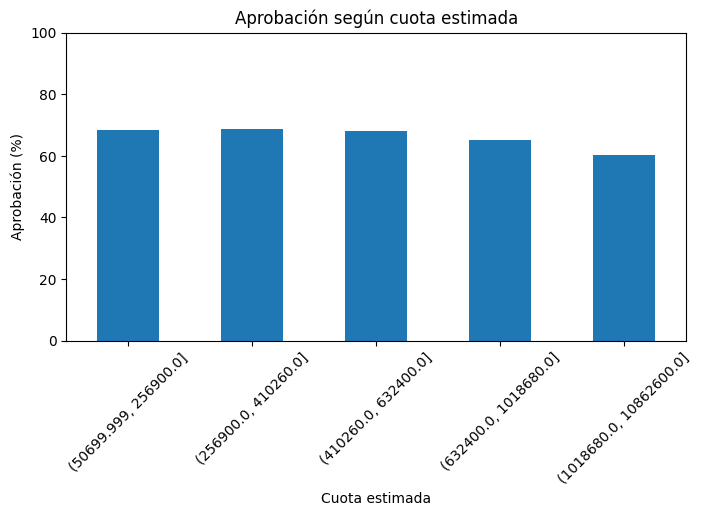

In [30]:
df["grupo_cuota"] = pd.qcut(
    df["cuota_estimada"],
    q=5,
    duplicates="drop"
)

aprobacion_cuota = df.groupby(
    "grupo_cuota",
    observed=True
)["aprobado"].mean() * 100

aprobacion_cuota.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Aprobación según cuota estimada")
plt.ylabel("Aprobación (%)")
plt.xlabel("Cuota estimada")
plt.ylim(0, 100)
plt.xticks(rotation=45)

plt.show()

### Score crediticio

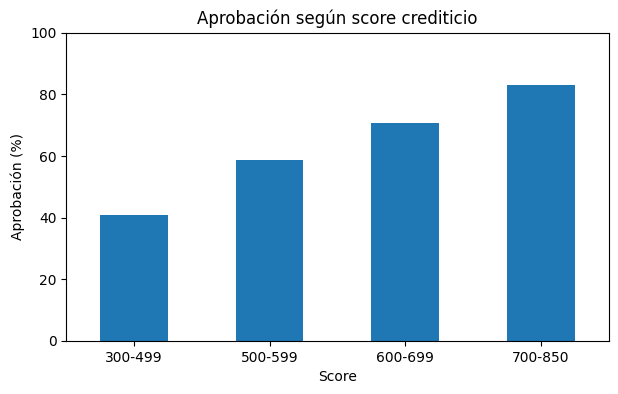

In [31]:
df["grupo_score"] = pd.cut(
    df["score_crediticio"],
    bins=[300, 500, 600, 700, 851],
    labels=[
        "300-499",
        "500-599",
        "600-699",
        "700-850"
    ],
    right=False
)

aprobacion_score = df.groupby(
    "grupo_score",
    observed=True
)["aprobado"].mean() * 100

aprobacion_score.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Aprobación según score crediticio")
plt.ylabel("Aprobación (%)")
plt.xlabel("Score")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

### DTI Previo

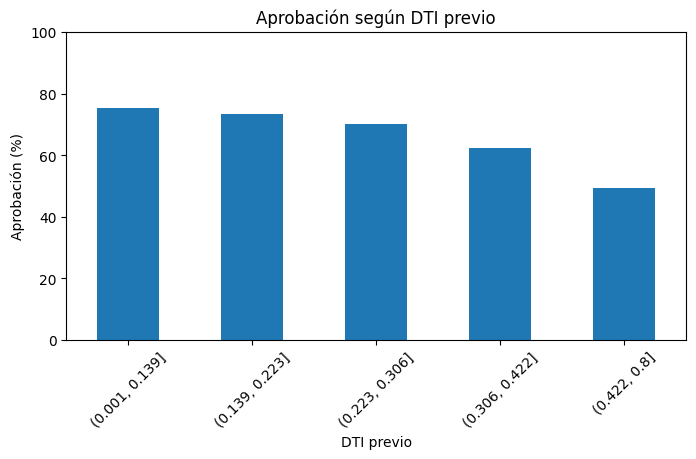

In [32]:
df["grupo_dti_previo"] = pd.qcut(
    df["dti_previo"],
    q=5,
    duplicates="drop"
)

aprobacion_dti_previo = df.groupby(
    "grupo_dti_previo",
    observed=True
)["aprobado"].mean() * 100

aprobacion_dti_previo.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Aprobación según DTI previo")
plt.ylabel("Aprobación (%)")
plt.xlabel("DTI previo")
plt.ylim(0, 100)
plt.xticks(rotation=45)

plt.show()

### DTI Total Proyectado

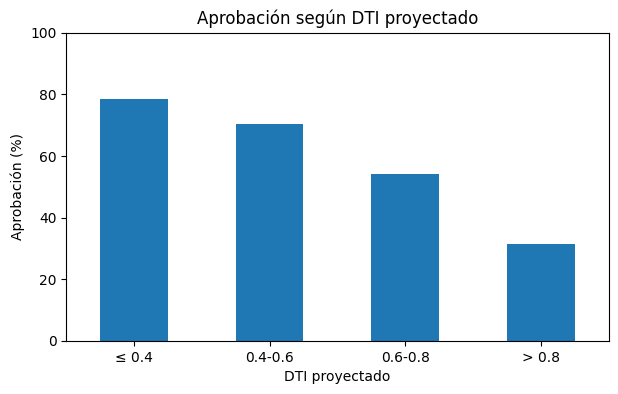

In [33]:
df["grupo_dti"] = pd.cut(
    df["dti_total_proyectado"],
    bins=[0, 0.4, 0.6, 0.8, np.inf],
    labels=[
        "≤ 0.4",
        "0.4-0.6",
        "0.6-0.8",
        "> 0.8"
    ]
)

aprobacion_dti = df.groupby(
    "grupo_dti",
    observed=True
)["aprobado"].mean() * 100

aprobacion_dti.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Aprobación según DTI proyectado")
plt.ylabel("Aprobación (%)")
plt.xlabel("DTI proyectado")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

## Conclusiones

- El dataset presenta una buena calidad inicial, sin valores nulos ni registros duplicados, por lo que no requiere tratamientos importantes de limpieza antes del modelado.
- La variable objetivo presenta un desbalance moderado: aproximadamente 66 % de los créditos fueron aprobados y 34 % no aprobados.
- Las variables que muestran una mayor relación con la aprobación son el score crediticio y los indicadores de endeudamiento DTI previo y DTI total proyectado.
- Se observa una relación clara entre el score crediticio y la aprobación: a medida que aumenta el score, aumenta también la proporción de créditos aprobados.
- El comportamiento del DTI es inverso: mayores niveles de endeudamiento, especialmente en el DTI total proyectado, están asociados con menores tasas de aprobación.
- Los solicitantes con mayores ingresos presentan, en general, una mayor tasa de aprobación. Sin embargo, el ingreso tiene una relación menos marcada con la decisión que el score crediticio y el DTI.
- El monto solicitado por sí solo presenta poca relación con la aprobación, lo que sugiere que resulta más relevante analizar la deuda en relación con la capacidad de pago del solicitante que considerar únicamente el valor absoluto solicitado.
- El número de personas a cargo muestra una relación negativa moderada con la aprobación, mientras que los plazos más largos presentan mayores tasas de aprobación, posiblemente debido a que generan cuotas mensuales menores.
- Algunas variables presentan correlaciones elevadas entre sí, especialmente monto_solicitado con cuota_estimada y dti_previo con dti_total_proyectado. Esta posible redundancia deberá considerarse durante la construcción del modelo.
- En conjunto, el análisis exploratorio sugiere que score_crediticio, dti_total_proyectado y dti_previo serán variables especialmente relevantes para predecir la aprobación de un crédito.